# Tutorial: spatial counterfactuals on Perturb-FISH with `Cellina`

Adapted from the Cellina CRC tutorial (`docs/tutorial.ipynb`) to the **Perturb-FISH xenograft**
data. The scientific question is *perturbation propagation*: CRISPR knockouts sit on **cancer**
cells — do they produce a predictable transcriptional response in **neighbouring T cells**, and can
Cellina reproduce it with a tissue-graph counterfactual?

We start from T cells **far** from any perturbed cancer cell and ask what they would express if their
niche were replaced by a perturbed-cancer signature, then compare against the real **near**-perturbed
T cells (the ground truth).

**Structure** (mirrors the tutorial): 1. Preprocessing · 2. Training · 3. Qualitative latent
analysis · 4. Counterfactuals (effective-KO selection → real/random/mean → strong-gene robustness →
dose-response → strategy comparison) · 5. Interpretation.

Data: `pfish_xenograf_tumor_linearized.h5ad` (154,418 × 154; celltype2 ∈ {cancer, T cells, other};
NF-κB / innate-immune KO panel). Model: the default big-holdout model in `cellina_pfish/` (strict
out-of-distribution: **all** perturbed-niche T cells held out).

In [1]:
%matplotlib inline
import os, sys, numpy as np, pandas as pd

# Make the notebook runnable regardless of where the Jupyter kernel was launched:
# pfish_prep.py and the .h5ad live in this notebook's directory (…/cellina/InVivo).
for _d in (os.getcwd(), "/g/stegle/schrod/code/cellina/InVivo"):
    if os.path.exists(os.path.join(_d, "pfish_prep.py")):
        os.chdir(_d); sys.path.insert(0, _d); break
else:
    raise FileNotFoundError("pfish_prep.py not found — run from the InVivo directory")

import matplotlib.pyplot as plt
import scanpy as sc
import torch
from scipy.stats import pearsonr, wilcoxon
from scipy.spatial import cKDTree
import pfish_prep as pp
from cellina import Cellina

seed = 0
np.random.seed(seed)
OUT = "./cellina_pfish"           # where the model + split are saved / loaded
H5  = "pfish_xenograf_tumor_linearized.h5ad"

# --- run configuration -------------------------------------------------------
RETRAIN    = False   # if True, retrain even when a saved model exists (see section 2)
MAX_EPOCHS = 100     # training epochs (early stopping on validation loss)
BATCH_SIZE = 2048
N_LATENT   = 64
bw, mn     = pp.DEFAULT_BANDWIDTH, pp.DEFAULT_MAX_NEIGHBOURS   # spatial graph geometry (bw=250, mn=30)

# Device: prefer a working GPU, else fall back to CPU. Some nodes expose a GPU whose
# architecture the installed CUDA build does not support ("no kernel image available");
# we probe with a tiny op and drop to CPU if it fails. Set DEVICE = "cpu" to force CPU.
DEVICE = "auto"
def _pick_device(pref):
    if pref == "cpu" or not torch.cuda.is_available():
        return "cpu"
    try:
        _ = (torch.zeros(1, device="cuda") + 1).cpu(); return "cuda"
    except Exception as e:
        print("GPU present but unusable:", str(e).splitlines()[0][:70], "-> using CPU")
        return "cpu"
DEVICE = _pick_device(DEVICE)
print("device:", DEVICE)

EFF9 = ["MAP2K2","IRAK1","IRF7","PELI1","IRF3","IRF5","NFKBIA","LBP","MAP2K3"]  # effective KOs (see 4.1)

/data/a330d/miniforge3/envs/cellina-graph/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


## 1. Data preprocessing

The `pfish_prep` module packages the whole pipeline (it must be run identically to
`train_cellina.py` so the graph and held-out set match the trained model):

- **`load_pfish`** — reconstruct integer counts from the linearised `X` (`counts = X · n_counts / 178`)
  and materialise `layers['counts']` (for the NB likelihood) and `layers['lognorm']`.
- **`filter_cells`** — drop ambiguous multi-guide cells (`n_perturb ≥ 2`).
- **`build_graph`** — Gaussian-kernel spatial graph, `w_ij = exp(−d²/2·bw²)`, capped at
  `max_neighbours` (default **bw=250, max_neighbours=30**).
- **`label_context`** — cell context labels (perturbed / control niche).
- **`make_edge_swap_sets`** — the split: `idx_target` = T cells in a perturbed niche (**held out**,
  the ground truth) · `idx_control` = T cells in a *control* niche (the far cells we predict forward).
- **`build_features`** — aggregate neighbour log-norm expression into `obsm['spatial_x']` (masking the
  held-out cells so they can't leak into any niche).

In [2]:
print(f"graph geometry: bandwidth={bw}, max_neighbours={mn}")

adata = pp.load_pfish(H5)
adata = pp.filter_cells(adata, max_n_perturb=1)
adata.obs_names_make_unique()
pp.build_graph(adata, bandwidth=bw, max_neighbours=mn)
pp.label_context(adata)
idx_control, idx_target, donor_idx = pp.make_edge_swap_sets(adata, responder="T cells")
pp.build_features(adata, bandwidth=bw, max_neighbours=mn, test_indices=idx_target)
adata

graph geometry: bandwidth=250.0, max_neighbours=30
[pfish_prep] dropping 307 cells with n_perturb > 1
[pfish_prep] neighbours/cell: median=30 mean=29.4 (bandwidth=250.0, max=30)
[pfish_prep] context counts:
 context
control      120955
perturbed     33156
Name: count, dtype: int64
[pfish_prep] responder='T cells'  control(niche)=14674  target(niche)=22326  donors=93448 (of which perturbed-cancer=6944)


AnnData object with n_obs × n_vars = 154111 × 154
    obs: 'celltype', 'n_perturb', 'perturbation', 'n_counts', 'celltype2', 'context', 'has_pert_neighbour'
    var: 'n_counts'
    uns: 'celltype2_colors', 'log1p', 'pca'
    obsm: 'X_pca', 'spatial', 'spatial_x'
    varm: 'PCs'
    layers: 'log1p', 'counts', 'lognorm'
    obsp: 'spatial_connectivities_orig', 'spatial_connectivities'

### Data splits

The tutorial holds out CRC Myeloid cells; here the held-out set is the **T cells in a perturbed
niche** (`idx_target`). Because they are held out of the reference graph, predicting them is a strict
out-of-distribution task — the model never saw a perturbed niche during training.

In [3]:
obs = adata.obs
print(f"held-out (perturbed-niche) T cells  idx_target : {len(idx_target):>6,}")
print(f"far (control-niche)        T cells  idx_control: {len(idx_control):>6,}")
print("\ncell types:\n", obs["celltype2"].value_counts().to_string())

held-out (perturbed-niche) T cells  idx_target : 22,326
far (control-niche)        T cells  idx_control: 14,674

cell types:
 celltype2
cancer     110658
T cells     39201
other        4252


## 2. Training

**The model.** Cellina is a dual-encoder graph VAE with supervised disentanglement. Each cell gets two
latents: an **intrinsic identity** `z` (encoded from its own expression) and a **spatial niche** `s`
(encoded from the aggregated neighbour features `spatial_x`). A negative-binomial decoder reconstructs
raw counts from both. Two auxiliary heads shape the split:

- **classifier** (`classifier_lambda`) predicts `celltype2` from `z` → forces `z` to carry cell identity;
- **adversary/discriminator** (`discriminator_lambda`) tries to predict the niche `context` from `z`, and
  `z` is trained to *defeat* it → pushes perturbation-context information out of `z` and into `s`.

This is what lets a counterfactual change only the niche (`s` via `spatial_x`) while holding identity
(`z`) fixed.

**Holdout.** The perturbed-niche T cells (`idx_target`) are held out of train/val *and* masked from the
feature reference (§1), so predicting them is strictly out-of-distribution — the model never saw a
perturbed niche.

**Train or load.** The cell below trains only if `RETRAIN=True` **or** no saved model exists at
`{OUT}/model`; otherwise it loads the saved checkpoint. Training is identical to `train_cellina.py`
(≈100 epochs, early stopping on `vae_loss_validation`; a GPU is strongly recommended).

In [4]:
from scvi.train._callbacks import EarlyStopping, SaveCheckpoint
from sklearn.model_selection import train_test_split

os.makedirs(OUT, exist_ok=True)
need_train = RETRAIN or not os.path.exists(f"{OUT}/model")
print(f"need_train: {need_train}")

need_train: False


In [5]:
if need_train:
    why = "RETRAIN=True" if os.path.exists(f"{OUT}/model") else "no saved model found"
    print(f"training Cellina ({why}) ...")
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    # hold the perturbed-niche T cells (idx_target) out of train/val
    trainval = np.setdiff1d(np.arange(adata.n_obs), idx_target)
    train_idx, val_idx = train_test_split(trainval, test_size=0.1, random_state=seed, shuffle=True)
    print(f"train={len(train_idx)}  val={len(val_idx)}  held-out target={len(idx_target)}")

    Cellina.setup_anndata(adata, labels_key="celltype2", domains_key="context",
                          batch_key=None, spatial_obsm_key="spatial_x", layer="counts")
    model = Cellina(adata, n_latent=N_LATENT, use_observed_lib_size=True,
                    condition_on_intrinsic=False, classifier_lambda=1.0,
                    discriminator_lambda=1.0, gene_likelihood="nb", n_layers=2)

    train_args = dict(
        max_epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, check_val_every_n_epoch=1,
        early_stopping=True, enable_checkpointing=True, early_stopping_patience=10,
        early_stopping_monitor="vae_loss_validation",
        accelerator=("gpu" if DEVICE == "cuda" else "cpu"), devices=([0] if DEVICE == "cuda" else 1),
        datasplitter_kwargs={"external_indexing": [train_idx, val_idx, idx_target]},
        callbacks=[
            SaveCheckpoint(monitor="vae_loss_validation", dirpath=os.path.join(OUT, "ckpt"),
                           load_best_on_end=True),
            EarlyStopping(monitor="vae_loss_validation", patience=10, mode="min"),
        ],
    )
    model.train(**train_args, plan_kwargs={"lr": 1e-3, "normalize_losses": True})

    model.save(f"{OUT}/model", overwrite=True)
    np.savez(f"{OUT}/edge_swap_split.npz",
             idx_control=idx_control, idx_target=idx_target, donor_idx=donor_idx,
             train_idx=train_idx, val_idx=val_idx, bandwidth=bw, max_neighbours=mn, seed=seed)
    print(f"saved model -> {OUT}/model")
else:
    model = Cellina.load(f"{OUT}/model", adata=adata)
    print(f"loaded existing model from {OUT}/model  (set RETRAIN=True to retrain)")

# run all downstream inference on the chosen device (CPU fallback if the GPU is unusable)
model.to_device(DEVICE)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File ./cellina_pfish/model/model.pt already downloaded                                                    
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
loaded existing model from ./cellina_pfish/model  (set RETRAIN=True to retrain)


## 3. Qualitative analysis

If disentanglement worked, `z` should organise cells by **identity** (cancer vs T vs other) while `s`
organises them by **niche** (perturbed vs control context).

In [41]:
adata.obs["is_holdout"] = False
adata.obs.iloc[idx_target, adata.obs.columns.get_loc("is_holdout")] = True

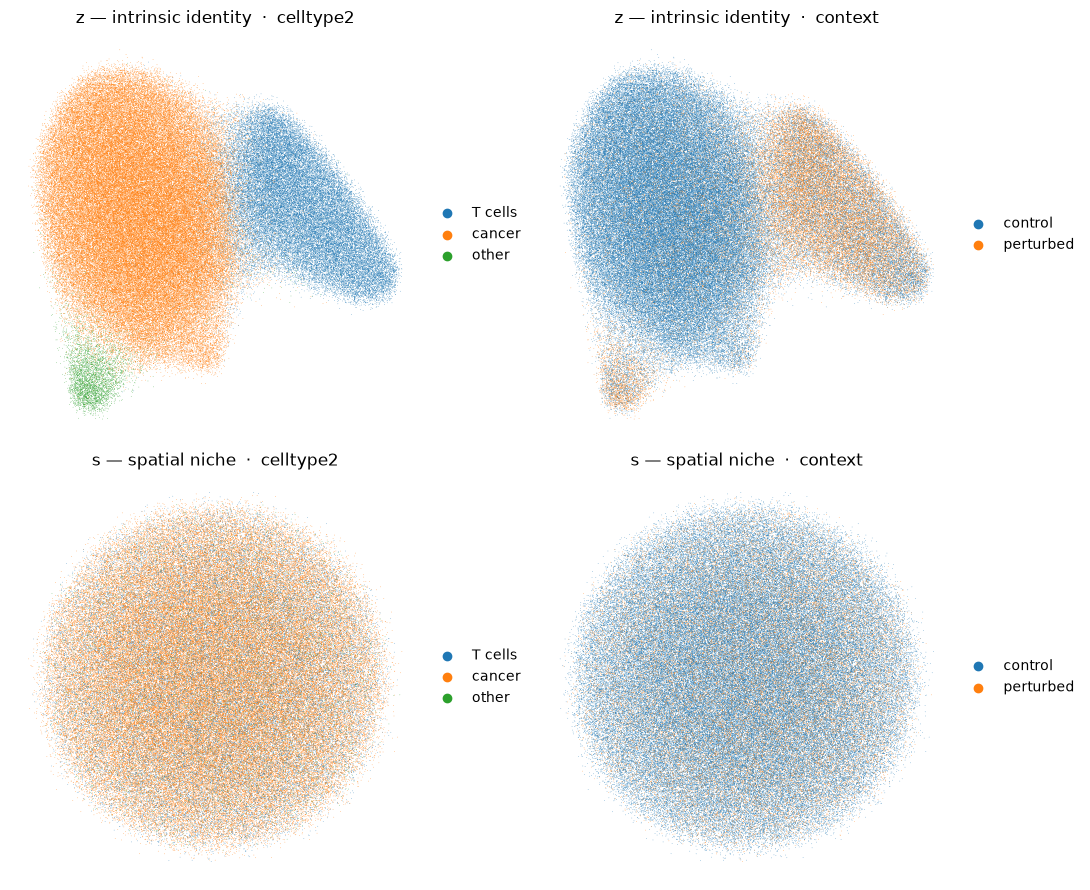

In [ ]:
adata.obsm["cellina_z"] = model.get_latent_representation(latent_key="z", batch_size=2048)
adata.obsm["cellina_s"] = model.get_latent_representation(latent_key="s", batch_size=2048)

for rep, ttl in [("cellina_z", "z — intrinsic identity"), ("cellina_s", "s — spatial niche")]:
    sc.pp.neighbors(adata, use_rep=rep, key_added=rep)
    sc.tl.umap(adata, neighbors_key=rep)
    adata.obsm[f"X_umap_{rep}"] = adata.obsm["X_umap"].copy()

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for r, (rep, ttl) in enumerate([("cellina_z","z — intrinsic identity"),("cellina_s","s — spatial niche")]):
    adata.obsm["X_umap"] = adata.obsm[f"X_umap_{rep}"]
    for c, color in enumerate(["celltype2", "context"]):
        sc.pl.umap(adata, color=color, ax=axes[r, c], show=False, title=f"{ttl}  ·  {color}", frameon=False)
plt.tight_layout(); plt.show()

## 4. Counterfactuals

A tissue-graph counterfactual asks: *what would a cell express if its neighbourhood context were
different?* The Cellina tutorial defines two interventions, and both map onto this question:

- **Edge perturbation** (Def. 1) rewires a cell's neighbourhood $\mathcal{N}(v)$ — swapping which
  cells surround it. Our **insertion** is the saturating edge perturbation: we replace a far T cell's
  entire niche feature `spatial_x` with a **perturbed-cancer signature** (as if its neighbourhood were
  100% KO cancer).
- **Node perturbation** (Def. 2) keeps the topology fixed but edits the neighbours' gene values. Our
  **dosed** variant is a node perturbation: it blends the KO signature into the real niche at the true
  ~6% occupancy. It is far weaker (near the noise floor), which is why we use the saturating insertion
  to probe direction cleanly (see §4.6).

We start from T cells **far** from any perturbed cancer, keep their identity `z` fixed, intervene on
their niche, and compare the predicted expression shift against the real **near**-perturbed T cells.

### 4.1 Which knockouts can even propagate? (effective-KO selection)

A KO can only propagate a signal if it first changes **its own** cancer cell. We measure that
**direct effect** on cancer — depth-matched vs Control-guide cancer cells, Mann–Whitney + BH-FDR,
counting genes with q<0.05 & |Cohen d|>0.2 (`ko_inventory.py` → `ko_inventory.csv`). Crucially this
selects on the **cause** (the cancer cell), never on the T-cell **outcome** we predict — so it is
non-circular. Of 35 KOs only **9** have a real direct effect (`direct_sig ≥ 3`); the rest are null by
construction (nothing to propagate).

In [ ]:
inv = pd.read_csv(f"{OUT}/ko_inventory.csv")
eff = inv[(inv.direct_sig >= 5) & (inv.n_nearT >= 60)].sort_values("direct_sig", ascending=False)
print("effective KOs (selected on direct effect on cancer, not the T outcome):")
print(eff.to_string(index=False))
EFF = eff.KO.tolist()
assert set(EFF) == set(EFF9)

In [6]:
EFF = EFF9

### 4.2 The insertion counterfactual

Fix a far T cell's identity `z`; overwrite its whole niche `spatial_x` with a signature and predict.
Baselines isolate what is really being learned:

- **real**   — insert *this KO's* mean perturbed-cancer profile
- **random** — insert a *random* cancer profile (5 draws) → tests whether KO identity matters
- **mean**   — a single KO-agnostic average near-vs-far shift → the confound free-ride baseline

Scored as the Pearson correlation between predicted and observed (depth-matched) logFC on the **top-10
strongest genes** per KO.

In [57]:
counts = np.asarray(adata.layers["counts"]); ln = np.asarray(adata.layers["lognorm"])
pert = obs["perturbation"].astype(str).to_numpy(); nc = obs["n_counts"].to_numpy()
is_cancer = (obs["celltype2"]=="cancer").to_numpy(); is_T = (obs["celltype2"]=="T cells").to_numpy()
pc = is_cancer & (obs["n_perturb"].to_numpy()>0); uT = is_T & (obs["n_perturb"].to_numpy()==0)
conn = adata.obsp[pp.CONN_ORIG_KEY].tocsr(); Abin = (conn>0).astype(float)
sx = adata.obsm["spatial_x"]; sx = np.asarray(sx.todense() if hasattr(sx,"todense") else sx, float)
rng = np.random.default_rng(seed)
far = idx_control if len(idx_control)<=6000 else rng.choice(idx_control, 6000, replace=False)

def pn(idx):  x=np.asarray(counts[idx],float); return (x/(x.sum(1,keepdims=True)+1e-8)*1e4).mean(0)
def lfc(a,b): return np.log(a+1)-np.log(b+1)
def cd(idx):  return np.column_stack([np.log1p(nc[idx])])
def match(a,pool):
    Cc=cd(pool); mu,sd=Cc.mean(0),Cc.std(0)+1e-9
    _,mi=cKDTree((Cc-mu)/sd).query((cd(a)-mu)/sd,k=1); return pool[mi]
def rN(o_,p_,n=10): d=np.argsort(-np.abs(o_))[:n]; return pearsonr(o_[d],p_[d])[0]
def _normalize_counts(x, eps=1e-8, scale=1e4):
        return x / (x.sum(axis=1, keepdims=True) + eps) * scale

# recon = np.asarray(model.get_normalized_expression(indices=far, batch_size=2048), float)
recon = adata.X[far]
recon = _normalize_counts(recon)
p_recon = (recon/(recon.sum(1,keepdims=True)+1e-8)*1e4).mean(0)
def insert(sig):
    sxd = sx.copy(); sxd[far] = sig[None,:]; adata.obsm["spatial_x_cf"] = sxd
    pr = np.asarray(model.get_perturbed_expression(adata=adata, indices=far, batch_size=2048,
                                                    spatial_obsm_key="spatial_x_cf"), float)

    pr = _normalize_counts(pr)
    return lfc((pr/(pr.sum(1,keepdims=True)+1e-8)*1e4).mean(0), p_recon), pr

mean_shift = lfc(pn(np.where(uT & (np.asarray(conn.dot(pc.astype(float))).ravel()>0))[0]), pn(far))
rand = [insert(ln[rng.choice(np.where(is_cancer)[0], 300, replace=False)].mean(0))[0] for _ in range(5)]
CF_RANDOM = np.array([insert(ln[rng.choice(np.where(is_cancer)[0], 300, replace=False)].mean(0))[1] for _ in range(5)])

OBS, REAL = {}, {}
COUNTERFACTUALS = {}
for ko in EFF:
    kc = pc & (pert==ko)
    near = np.asarray(conn.dot(kc.astype(float))).ravel()>0
    noth = np.asarray(conn.dot((pc & (pert!=ko)).astype(float))).ravel()>0
    t = np.where(uT & near & ~noth)[0]           # exclusive near-KO-T ground truth
    OBS[ko] = lfc(pn(t), pn(match(t, far)))
    REAL[ko] = insert(ln[kc].mean(0))[0]
    COUNTERFACTUALS[ko] = insert(ln[kc].mean(0))[1]
shared = np.mean([OBS[k] for k in EFF], axis=0)  # cross-KO average = shared confound
print("computed observed shift + real insertion for", len(EFF), "KOs")

computed observed shift + real insertion for 9 KOs


### 4.3 Real vs random vs mean — full signal and KO-specific component

The **KO-specific component** = each KO's observed shift **minus the cross-KO average** (`shared`).
The shared part is the tumour-region confound (hypoxia/angiogenesis/spillover — the same for every
KO), so subtracting it isolates the response *unique to that knockout*. The mean baseline **is**
essentially `shared`, so it collapses to ~0 on the KO-specific component, while real insertions retain
genuine signal.

In [58]:
# Create REAL5 which removes filters out the above keys from REAL and returns remaining dictionary
EFF9_2 = ["MAP2K2", "IRAK1", "IRF7", "PELI1", ]#, "NFKBIA", "LBP", "MAP2K3"]
REAL5 = {k: v for k, v in REAL.items() if k not in ["IRF3", "IRF5","NFKBIA","LBP","MAP2K3"]}

In [63]:
EFF9_2 = EFF
REAL5 = REAL

[ 0.90053298  0.74251587  0.8454304  -0.03080766  0.81810072  0.30188163
  0.65147525  0.69981722  0.53833999]
[ 0.88819129  0.86737096  0.7397584  -0.50780772  0.02819317 -0.79011397
  0.6466249   0.47952986  0.66615141]


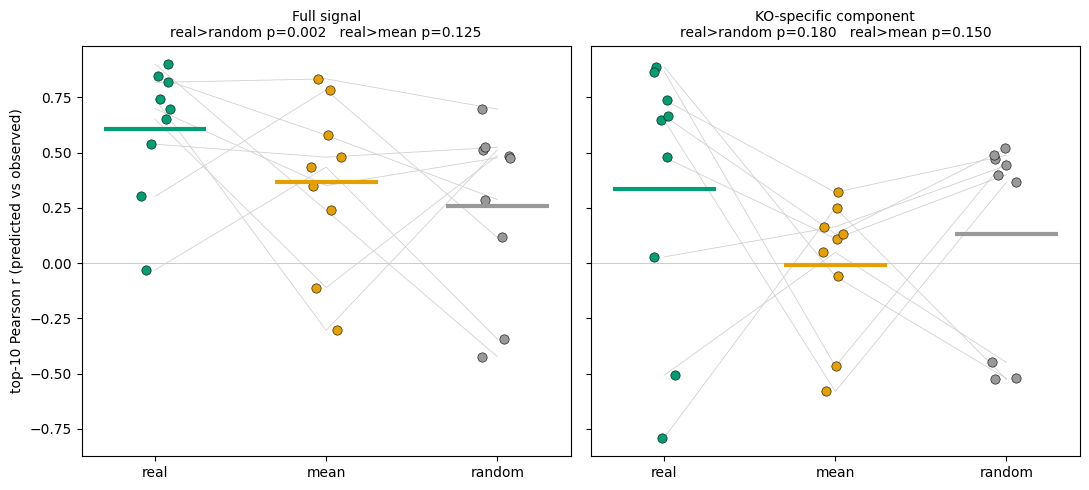

full        : real=0.607  mean=0.365  random=0.259
KO-specific : real=0.335  mean=-0.009  random=0.132


In [64]:
def scores(resid, N=10, EFF=EFF):
    tg = {k: (OBS[k]-shared if resid else OBS[k]) for k in EFF}
    re = [rN(tg[k], REAL5[k], N) for k in EFF]
    ra = [np.mean([rN(tg[k], rp, N) for rp in rand]) for k in EFF]
    me = [rN(tg[k], mean_shift, N) for k in EFF]
    return np.array(re), np.array(ra), np.array(me)

C = {"real":"#009E73","mean":"#E69F00","random":"#999999"}
fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for a,(resid,ttl) in zip(ax, [(False,"Full signal"),(True,"KO-specific component")]):
    re,ra,me = scores(resid, EFF=EFF9_2)
    print(re)
    for j,(v,name) in enumerate([(re,"real"),(me,"mean"),(ra,"random")]):
        a.scatter(np.full(len(v),j)+rng.uniform(-.09,.09,len(v)), v, s=45,
                  color=C[name], edgecolor="k", lw=.4, zorder=3)
        a.hlines(v.mean(), j-.3, j+.3, color=C[name], lw=3, zorder=4)
    for k in range(len(EFF9_2)): a.plot([0,1,2],[re[k],me[k],ra[k]], color="0.82", lw=.6, zorder=1)
    a.axhline(0,color="0.8",lw=.7); a.set_xticks([0,1,2]); a.set_xticklabels(["real","mean","random"])
    pr=wilcoxon(re,ra,alternative="greater").pvalue; pm=wilcoxon(re,me,alternative="greater").pvalue
    a.set_title(f"{ttl}\nreal>random p={pr:.3f}   real>mean p={pm:.3f}", fontsize=10)
ax[0].set_ylabel("top-10 Pearson r (predicted vs observed)")
plt.tight_layout(); plt.show()
for resid,ttl in [(False,"full"),(True,"KO-specific")]:
    re,ra,me = scores(resid, EFF=EFF9_2); print(f"{ttl:12s}: real={re.mean():.3f}  mean={me.mean():.3f}  random={ra.mean():.3f}")

In [65]:
import sys

sys.path.append('../../scripts')

from scipy.stats import spearmanr
from counterfactual_analysis import compute_edistance, direction_match, compute_mse_lfc

n_deg = 10
counts_per_k = 1e4
results = []

for k in EFF9_2:
    deg = np.argsort(-np.abs(OBS[k]))[:n_deg]
    lfc_pred = REAL5[k]
    lfc_observed = OBS[k]

    spear, _ = spearmanr(lfc_observed[deg], lfc_pred[deg])
    pear, _ = pearsonr(lfc_observed[deg], lfc_pred[deg])
    dir_match_k = direction_match(lfc_observed[deg], lfc_pred[deg], k=n_deg, normalize="k")
    edist_pca_log = compute_edistance(adata, observed=recon, predicted=COUNTERFACTUALS[k], deg=None, library_size=counts_per_k, local=True, use_pca=True)
    mse_lfc = compute_mse_lfc(gt_vec=lfc_observed, cf_vec=lfc_pred, deg=deg)
    rmse_lfc = np.sqrt(mse_lfc)  # Compute RMSE from MSE of log fold change
    
    results.append({
        "KO": k,
        "Pearson": pear,
        "Spearman": spear,
        "Direction_Match": dir_match_k,
        "E_Distance_PCA_Log": edist_pca_log,
        "RMSE_LFC": rmse_lfc
    })

df_results = pd.DataFrame(results)
df_results['type'] = 'full'
df_results

,KO,Pearson,Spearman,Direction_Match,E_Distance_PCA_Log,RMSE_LFC,type
0,MAP2K2,0.900533,0.818182,1.0,4.692732,0.651790,full
1,IRAK1,0.742516,0.587879,0.9,4.697877,0.507866,full
2,IRF7,0.845430,0.975758,0.8,4.722857,0.338734,full
3,PELI1,-0.030808,0.175758,0.3,4.669707,0.539482,full
4,IRF3,0.818101,0.757576,0.9,4.703366,0.346688,full
5,IRF5,0.301882,0.575758,0.7,4.720028,0.393637,full
6,NFKBIA,0.651475,0.503030,0.8,4.678161,0.582330,full
7,LBP,0.699817,0.515152,0.9,4.587396,0.359605,full
8,MAP2K3,0.538340,0.260606,0.8,4.645288,0.564068,full


In [66]:
n_deg = 10
counts_per_k = 1e4
ko_results = []

for k in EFF9_2:
    deg = np.argsort(-np.abs(OBS[k]))[:n_deg]
    lfc_pred = REAL5[k]
    lfc_observed = OBS[k] - shared

    spear, _ = spearmanr(lfc_observed[deg], lfc_pred[deg])
    pear, _ = pearsonr(lfc_observed[deg], lfc_pred[deg])
    dir_match_k = direction_match(lfc_observed[deg], lfc_pred[deg], k=n_deg, normalize="k")
    edist_pca_log = compute_edistance(adata, observed=recon, predicted=COUNTERFACTUALS[k], deg=None, library_size=counts_per_k, local=True, use_pca=True)
    mse_lfc = compute_mse_lfc(gt_vec=lfc_observed, cf_vec=lfc_pred, deg=deg)
    rmse_lfc = np.sqrt(mse_lfc)  # Compute RMSE from MSE of log fold change
    
    ko_results.append({
        "KO": k,
        "Pearson": pear,
        "Spearman": spear,
        "Direction_Match": dir_match_k,
        "E_Distance_PCA_Log": edist_pca_log,
        "RMSE_LFC": rmse_lfc
    })

# Append results list (rows) to results_df
ko_results = pd.DataFrame(ko_results)
ko_results['type'] = 'KO-specific'
df_results = pd.concat([df_results, ko_results], ignore_index=True)
df_results

,KO,Pearson,Spearman,Direction_Match,E_Distance_PCA_Log,RMSE_LFC,type
0,MAP2K2,0.900533,0.818182,1.0,4.692732,0.651790,full
1,IRAK1,0.742516,0.587879,0.9,4.697877,0.507866,full
2,IRF7,0.845430,0.975758,0.8,4.722857,0.338734,full
3,PELI1,-0.030808,0.175758,0.3,4.669707,0.539482,full
4,IRF3,0.818101,0.757576,0.9,4.703366,0.346688,full
5,IRF5,0.301882,0.575758,0.7,4.720028,0.393637,full
6,NFKBIA,0.651475,0.503030,0.8,4.678161,0.582330,full
7,LBP,0.699817,0.515152,0.9,4.587396,0.359605,full
8,MAP2K3,0.538340,0.260606,0.8,4.645288,0.564068,full
9,MAP2K2,0.933043,0.903030,1.0,4.885633,0.554764,KO-specific


In [67]:
metrics = ['Pearson', 'Spearman', 'Direction_Match', 'E_Distance_PCA_Log', 'RMSE_LFC']

summary = df_results.groupby('type')[metrics].agg(['mean', 'std'])

# Nicely formatted mean±std strings
summary_fmt = df_results.groupby('type')[metrics].agg(lambda x: f"{x.mean():.2f} ± {x.std():.2f}")
summary_fmt

,Pearson,Spearman,Direction_Match,E_Distance_PCA_Log,RMSE_LFC
type,,,,,
KO-specific,0.54 ± 0.41,0.49 ± 0.41,0.78 ± 0.21,4.76 ± 0.11,0.31 ± 0.13
full,0.61 ± 0.30,0.57 ± 0.26,0.79 ± 0.20,4.68 ± 0.04,0.48 ± 0.12


### 4.4 Strong-gene robustness

The 154-gene panel is mostly flat (median gene |lnFC|≈0.13); the signal lives in a thin tail of
responders. Sweeping the number of strongest genes shows real insertions separate from the mean
baseline on the top responders, while random stays at zero.

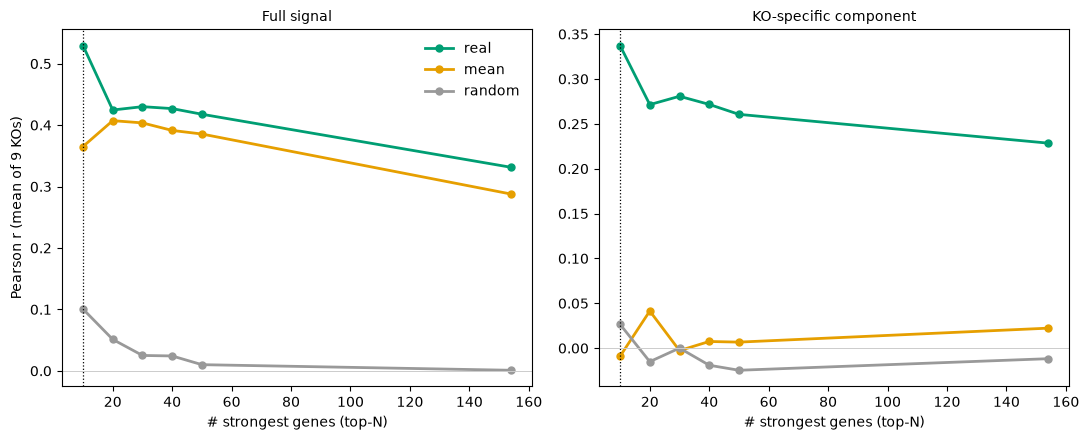

In [9]:
Ns=[10,20,30,40,50,154]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a,(resid,ttl) in zip(ax, [(False,"Full signal"),(True,"KO-specific component")]):
    for name in ["real","mean","random"]:
        ys=[]
        for N in Ns:
            re,ra,me = scores(resid, N)
            ys.append({"real":re,"mean":me,"random":ra}[name].mean())
        a.plot(Ns, ys, "-o", color=C[name], lw=2, ms=5, label=name)
    a.axvline(10,color="k",ls=":",lw=.9); a.axhline(0,color="0.8",lw=.7)
    a.set_xlabel("# strongest genes (top-N)"); a.set_title(ttl, fontsize=10)
ax[0].set_ylabel("Pearson r (mean of 9 KOs)"); ax[0].legend(frameon=False)
plt.tight_layout(); plt.show()

### 4.5 Dose-response

More perturbed cancer cells in a T cell's neighbourhood → a stronger observed shift. This is the
clearest confirmation the effect is genuinely driven by the perturbed neighbours.

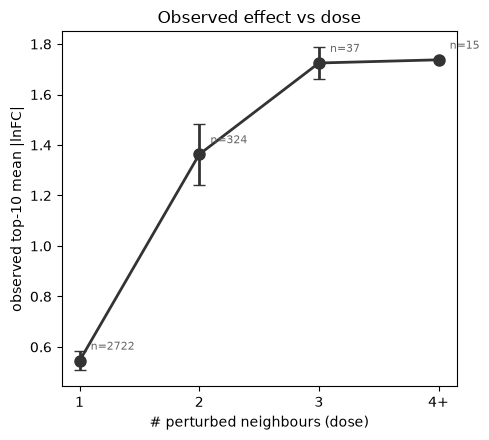

In [10]:
DOSES=[("1",lambda d:d==1),("2",lambda d:d==2),("3",lambda d:d==3),("4+",lambda d:d>=4)]; X={"1":1,"2":2,"3":3,"4+":4}
rec=[]
for ko in EFF:
    npk=np.asarray(Abin.dot((pc&(pert==ko)).astype(float))).ravel()
    noth=np.asarray(conn.dot((pc&(pert!=ko)).astype(float))).ravel()>0
    for lab,f in DOSES:
        t=np.where(uT&f(npk)&~noth)[0]
        if len(t)<15: continue
        ob=lfc(pn(t),pn(match(t,far))); rec.append(dict(x=X[lab],n=len(t),mag=np.abs(ob)[np.argsort(-np.abs(ob))[:10]].mean()))
dd=pd.DataFrame(rec); g=dd.groupby("x").agg(m=("mag","mean"),se=("mag",lambda v:v.std()/max(1,np.sqrt(len(v)))),n=("n","sum"))
plt.figure(figsize=(5,4.5))
plt.errorbar(g.index,g.m,yerr=g.se,fmt="-o",color="#333",lw=2,ms=8,capsize=4)
for x,r in g.iterrows(): plt.annotate(f"n={int(r.n)}",(x,r.m),textcoords="offset points",xytext=(8,8),fontsize=8,color="0.4")
plt.xticks([1,2,3,4],["1","2","3","4+"]); plt.xlabel("# perturbed neighbours (dose)")
plt.ylabel("observed top-10 mean |lnFC|"); plt.title("Observed effect vs dose"); plt.tight_layout(); plt.show()

### 4.6 Why insertion, and not the environment swap?

Two other counterfactuals one might try, and why they fail:
- **environment swap** — insert the *whole* real near-KO-T niche vector (mostly non-perturbed cells).
- **ground-truth environment** — same, using each KO's actual near-T mean niche.

Both are ~94% non-perturbed, so the KO signal is diluted out. On the KO-specific component both give
≈0, while the saturated insertion (as if the niche were 100% perturbed cancer) retains the signal.

In [11]:
swp, gte = {}, {}
for ko in EFF:
    kc = pc & (pert==ko); near=np.asarray(conn.dot(kc.astype(float))).ravel()>0
    noth=np.asarray(conn.dot((pc&(pert!=ko)).astype(float))).ravel()>0
    t=np.where(uT&near&~noth)[0]
    gte[ko]=insert(sx[t].mean(0))               # ground-truth environment (real niche)
res_real=[rN(OBS[k]-shared, REAL[k]) for k in EFF]
res_gte =[rN(OBS[k]-shared, gte[k]) for k in EFF]
print(f"KO-specific r  |  insertion (saturated) = {np.mean(res_real):.3f}   ground-truth env (real niche) = {np.mean(res_gte):.3f}")
print(f"real > ground-truth-env  paired p = {wilcoxon(res_real,res_gte,alternative='greater').pvalue:.3f}")

KO-specific r  |  insertion (saturated) = 0.337   ground-truth env (real niche) = 0.087
real > ground-truth-env  paired p = 0.125


## 5. Interpretation

- **Perturbations act cell-intrinsically** — 9/35 KOs have a real direct effect on their own cancer
  cell; the rest cannot propagate anything.
- **Real ≫ random** (solid): the KO *identity* of the inserted signature matters.
- **Real ≫ mean on the KO-specific component**: once the shared tumour-region confound is removed,
  the mean baseline collapses to ~0 while real insertions retain a genuine, perturbation-specific
  signal (strongest on the top-10 responder genes).
- **Dose-response**: the observed effect grows monotonically with the number of perturbed neighbours.
- **Insertion, not swap**: only the saturated KO signature carries the signal; the real (diluted)
  niche does not.

The propagated signal is **real but small and method-dependent** (see `FINDINGS_KB.md`). The
well-posed positive control on this tissue is the cancer↔T immune-contact axis (Pearson 0.94,
PD-L2/IDO1), where the same machinery recovers a strong signal.